In [27]:
!pip install kaggle

In [28]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"aminetoumohamed","key":"6c152a9fc8418eb4b608939c0e43db59"}'}

In [29]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [30]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
skin-cancer-mnist-ham10000.zip: Skipping, found more recently modified local copy (use --force to force download)


In [31]:
!unzip skin-cancer-mnist-ham10000.zip

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: ham10000_images_part_2/ISIC_0029338.jpg  
  inflating: ham10000_images_part_2/ISIC_0029339.jpg  
  inflating: ham10000_images_part_2/ISIC_0029340.jpg  
  inflating: ham10000_images_part_2/ISIC_0

In [32]:
import pandas as pd

df_balanced = pd.read_csv("HAM10000_metadata.csv")

print(df_balanced.head())
print(df_balanced.info())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None


Partie: Analyse des donnes

In [33]:
print(df_balanced.describe())

               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


In [34]:
print(df_balanced.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


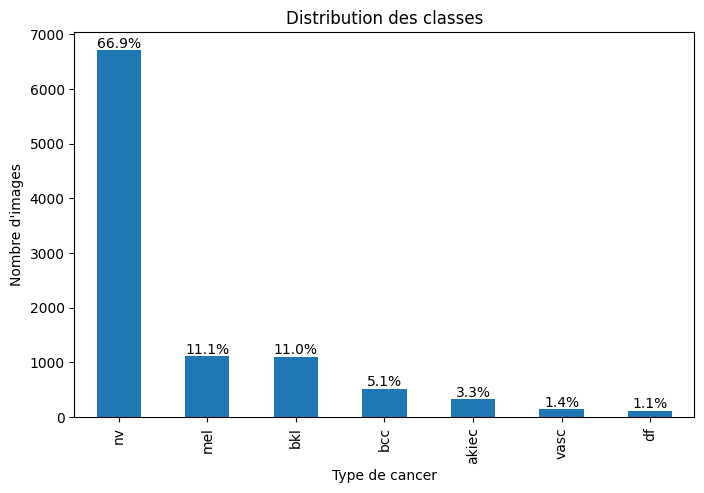

In [35]:
import matplotlib.pyplot as plt

counts = df_balanced['dx'].value_counts()

plt.figure(figsize=(8,5))
counts.plot(kind='bar')
plt.title("Distribution des classes")
plt.xlabel("Type de cancer")
plt.ylabel("Nombre d'images")

# ajouter pourcentage
for i, v in enumerate(counts):
    plt.text(i, v + 50, f"{(v/len(df_balanced)*100):.1f}%", ha='center')

plt.show()

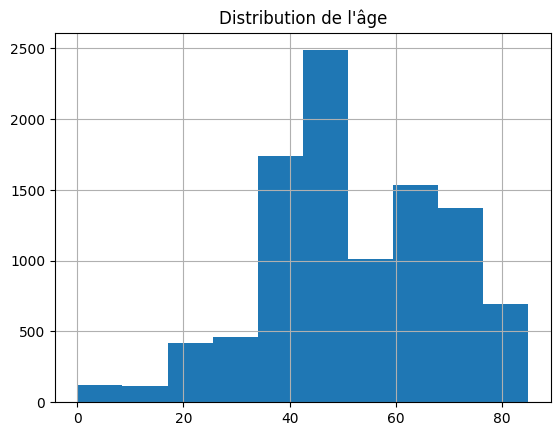

In [36]:
df_balanced['age'].hist()
plt.title("Distribution de l'âge")
plt.show()

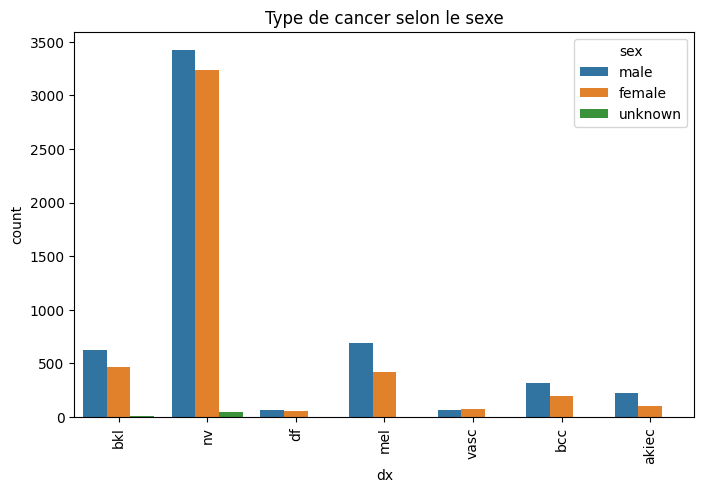

In [37]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='dx', hue='sex', data=df_balanced)
plt.xticks(rotation=90)
plt.title("Type de cancer selon le sexe")
plt.show()

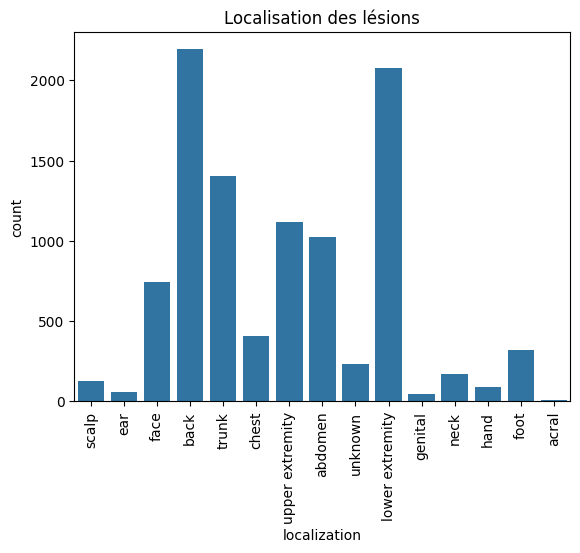

In [38]:
sns.countplot(x='localization', data=df_balanced)
plt.xticks(rotation=90)
plt.title("Localisation des lésions")
plt.show()

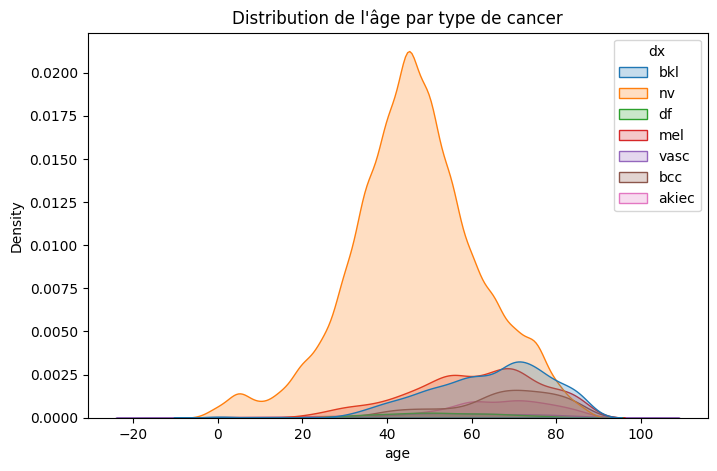

In [39]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_balanced, x='age', hue='dx', fill=True)
plt.title("Distribution de l'âge par type de cancer")
plt.show()

partie : Netoyage

In [40]:
# vérifier
print(df_balanced.isnull().sum())

# remplir l'âge par la médiane
df_balanced['age'].fillna(df_balanced['age'].median(), inplace=True)

# remplir le sexe par la valeur la plus fréquente
df_balanced['sex'].fillna(df_balanced['sex'].mode()[0], inplace=True)

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


/tmp/ipykernel_5557/3168430612.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_balanced['age'].fillna(df_balanced['age'].median(), inplace=True)
/tmp/ipykernel_5557/3168430612.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [41]:
df_balanced.drop_duplicates(inplace=True)

correction des valeurs manquants

In [42]:
print(df_balanced.isnull().sum())

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


suppression des doublons

In [43]:
print(df_balanced.duplicated().sum())

0


# corrige des erreurs

In [44]:
df_balanced = pd.read_csv("HAM10000_metadata.csv")

In [45]:
print(df_balanced['sex'].value_counts(dropna=False))

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64


In [46]:
df_balanced['sex'].fillna(df_balanced['sex'].mode()[0], inplace=True)

/tmp/ipykernel_5557/493999957.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_balanced['sex'].fillna(df_balanced['sex'].mode()[0], inplace=True)


In [47]:
df_balanced.columns = df_balanced.columns.str.strip()

In [48]:
df_balanced.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_balanced['label'] = le.fit_transform(df_balanced['dx'])

In [50]:
import os
import shutil
import pandas as pd

df_balanced = pd.read_csv("/content/HAM10000_metadata.csv")

base_dir = "/content/skin_dataset"
os.makedirs(base_dir, exist_ok=True)

# créer dossiers classes
for label in df_balanced['dx'].unique():
    os.makedirs(os.path.join(base_dir, label), exist_ok=True)

path1 = "/content/HAM10000_images_part_1"
path2 = "/content/HAM10000_images_part_2"

count = 0

for i, row in df_balanced.iterrows():
    img = row['image_id'] + ".jpg"
    label = row['dx']

    src1 = os.path.join(path1, img)
    src2 = os.path.join(path2, img)
    dst = os.path.join(base_dir, label, img)

    if os.path.exists(src1):
        shutil.copy(src1, dst)
        count += 1
    elif os.path.exists(src2):
        shutil.copy(src2, dst)
        count += 1

print("Images copiées:", count)

Images copiées: 10015


In [59]:
import os
import shutil
import random

# Répertoires
base_dir = "/content/skin_dataset"
output_dir = "/content/skin_split"

# Créer les dossiers train/val/test
for split in ["train", "val", "test"]:
    for cls in os.listdir(base_dir):
        class_path = os.path.join(base_dir, cls)

        if os.path.isdir(class_path):
            os.makedirs(
                os.path.join(output_dir, split, cls),
                exist_ok=True
            )

# Fixer la graine pour la reproductibilité
random.seed(42)

# Répartition des images
for cls in os.listdir(base_dir):

    class_path = os.path.join(base_dir, cls)

    if not os.path.isdir(class_path):
        continue

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    random.shuffle(images)

    n = len(images)

    train_end = int(0.70 * n)
    val_end = int(0.85 * n)

    for i, img in enumerate(images):

        src = os.path.join(class_path, img)

        if i < train_end:
            dst = os.path.join(
                output_dir,
                "train",
                cls,
                img
            )

        elif i < val_end:
            dst = os.path.join(
                output_dir,
                "val",
                cls,
                img
            )

        else:
            dst = os.path.join(
                output_dir,
                "test",
                cls,
                img
            )

        shutil.copy2(src, dst)

print("Dataset divisé avec succès !")

Dataset divisé avec succès !


Transformations des donnes (Data Augmentation) et DataLoaders

In [60]:
# /content/skin_split/
# ├── train/
# ├── val/
# └── test/

import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Paramètres
BATCH_SIZE = 32
IMG_SIZE = 224

dataset_dir = "/content/skin_split"

# ==========================
# Augmentation Train
# ==========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==========================
# Validation / Test
# ==========================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==========================
# Datasets
# ==========================
train_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_dir, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_dir, "val"),
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_dir, "test"),
    transform=test_transform
)

# ==========================
# DataLoaders
# ==========================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# ==========================
# Vérification
# ==========================
print("Classes :", train_dataset.classes)
print("Nombre de classes :", len(train_dataset.classes))
print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

images, labels = next(iter(train_loader))

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)

Classes : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Nombre de classes : 7
Train : 9765
Validation : 3845
Test : 3862
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])


Sous-échantillonnage à 3 000 images (Stratifié)

In [61]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42 # Définition de la graine pour la reproductibilité

# 1. Recharger les métadonnées propres
df_metadata = pd.read_csv("/content/HAM10000_metadata.csv")
df_metadata['age'].fillna(df_metadata['age'].median(), inplace=True)
df_metadata['sex'].fillna(df_metadata['sex'].mode()[0], inplace=True)

# 2. Échantillonnage stratifié pour obtenir exactement 3000 images
# On s'assure que la proportion de chaque type de cancer (dx) est conservée
total_sample_size = 3000
df_sampled, _ = train_test_split(
    df_metadata,
    train_size=total_sample_size,
    stratify=df_metadata['dx'],
    random_state=SEED
)

print("Distribution des 3000 images sélectionnées :")
print(df_sampled['dx'].value_counts())

# 3. Séparation en Train (70%), Val (15%), Test (15%) de manière stratifiée
df_train, df_temp = train_test_split(df_sampled, train_size=0.70, stratify=df_sampled['dx'], random_state=SEED)
df_val, df_test = train_test_split(df_temp, train_size=0.50, stratify=df_temp['dx'], random_state=SEED)

# 4. Création de la nouvelle structure de dossiers réduite
reduced_base_dir = "/content/ham10000_reduced"
path1 = "/content/HAM10000_images_part_1"
path2 = "/content/HAM10000_images_part_2"

splits = {'train': df_train, 'val': df_val, 'test': df_test}

# Supprimer le dossier s'il existe déjà pour éviter les doublons
if os.path.exists(reduced_base_dir):
    shutil.rmtree(reduced_base_dir)

for split_name, split_df in splits.items():
    for _, row in split_df.iterrows():
        img_name = row['image_id'] + ".jpg"
        label = row['dx']

        # Créer le sous-dossier de la classe si inexistant
        dest_folder = os.path.join(reduced_base_dir, split_name, label)
        os.makedirs(dest_folder, exist_ok=True)

        # Trouver la source de l'image
        src1 = os.path.join(path1, img_name)
        src2 = os.path.join(path2, img_name)
        src = src1 if os.path.exists(src1) else src2

        if os.path.exists(src):
            shutil.copy(src, os.path.join(dest_folder, img_name))

print("\nStructure des dossiers créée avec succès pour 3000 images !")

/tmp/ipykernel_5557/2563709381.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_metadata['age'].fillna(df_metadata['age'].median(), inplace=True)
/tmp/ipykernel_5557/2563709381.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

Distribution des 3000 images sélectionnées :
dx
nv       2009
mel       333
bkl       329
bcc       154
akiec      98
vasc       43
df         34
Name: count, dtype: int64

Structure des dossiers créée avec succès pour 3000 images !


Bloc DL — Extraction de Features Profondes (ResNet18

In [62]:
import torch.nn as nn
import torchvision.models as models

# Définir le dispositif (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du dispositif : {device}")

# 1. Configuration du modèle pré-entraîné ResNet18
# Charger le modèle ResNet18 pré-entraîné sur ImageNet
model_resnet = models.resnet18(pretrained=True)

# Retirer la couche de classification finale et la remplacer par une couche d'identité
# Cela nous permet d'obtenir les caractéristiques (features) de l'avant-dernière couche
model_resnet.fc = nn.Identity()

# Mettre le modèle en mode évaluation (important pour la feature extraction)
# Cela désactive le dropout et s'assure que les statistiques de Batch Normalization ne sont pas mises à jour
model_resnet.eval()

# Déplacer le modèle vers le dispositif choisi (GPU/CPU)
model_resnet = model_resnet.to(device)

print("Modèle ResNet18 configuré pour l'extraction de caractéristiques.")

Utilisation du dispositif : cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Modèle ResNet18 configuré pour l'extraction de caractéristiques.


In [63]:
import torch
from tqdm import tqdm

# Fonction pour extraire les caractéristiques
def extract_features(dataloader, model, device):
    features_list = []
    labels_list = []
    with torch.no_grad(): # Désactiver le calcul des gradients pour l'inférence
        for inputs, labels in tqdm(dataloader, desc="Extraction de caractéristiques"):
            inputs = inputs.to(device)
            features = model(inputs) # Obtenir les caractéristiques
            features_list.append(features.cpu()) # Déplacer les caractéristiques vers le CPU pour le stockage
            labels_list.append(labels.cpu()) # Déplacer les labels vers le CPU pour le stockage

    # Concaténer toutes les caractéristiques et labels en un seul tenseur
    all_features = torch.cat(features_list, dim=0)
    all_labels = torch.cat(labels_list, dim=0)
    return all_features, all_labels

print("Fonction 'extract_features' définie.")

Fonction 'extract_features' définie.


Nous allons maintenant extraire les caractéristiques profondes pour chaque ensemble (entraînement, validation, test) et les stocker.

In [64]:
# Extraction et stockage des activations (features)
print("Extraction des caractéristiques d'entraînement...")
train_features, train_labels = extract_features(train_loader, model_resnet, device)

print("Extraction des caractéristiques de validation...")
val_features, val_labels = extract_features(val_loader, model_resnet, device)

print("Extraction des caractéristiques de test...")
test_features, test_labels = extract_features(test_loader, model_resnet, device)

print(f"Taille des caractéristiques d'entraînement : {train_features.shape}")
print(f"Taille des labels d'entraînement : {train_labels.shape}")
print(f"Taille des caractéristiques de validation : {val_features.shape}")
print(f"Taille des labels de validation : {val_labels.shape}")
print(f"Taille des caractéristiques de test : {test_features.shape}")
print(f"Taille des labels de test : {test_labels.shape}")

Extraction des caractéristiques d'entraînement...


Extraction de caractéristiques: 100%|██████████| 306/306 [02:34<00:00,  1.99it/s]


Extraction des caractéristiques de validation...


Extraction de caractéristiques: 100%|██████████| 121/121 [00:49<00:00,  2.45it/s]


Extraction des caractéristiques de test...


Extraction de caractéristiques: 100%|██████████| 121/121 [00:48<00:00,  2.50it/s]

Taille des caractéristiques d'entraînement : torch.Size([9765, 512])
Taille des labels d'entraînement : torch.Size([9765])
Taille des caractéristiques de validation : torch.Size([3845, 512])
Taille des labels de validation : torch.Size([3845])
Taille des caractéristiques de test : torch.Size([3862, 512])
Taille des labels de test : torch.Size([3862])


##  Réduction de Dimensionnalité (ACP)

In [65]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Convertir les tenseurs PyTorch en tableaux NumPy pour Scikit-learn
X_train = train_features.numpy()
Y_train = train_labels.numpy()
X_val = val_features.numpy()
Y_val = val_labels.numpy()
X_test = test_features.numpy()
Y_test = test_labels.numpy()

print("Caractéristiques converties en tableaux NumPy.")
print(f"Taille X_train: {X_train.shape}")
print(f"Taille X_val: {X_val.shape}")
print(f"Taille X_test: {X_test.shape}")

Caractéristiques converties en tableaux NumPy.
Taille X_train: (9765, 512)
Taille X_val: (3845, 512)
Taille X_test: (3862, 512)


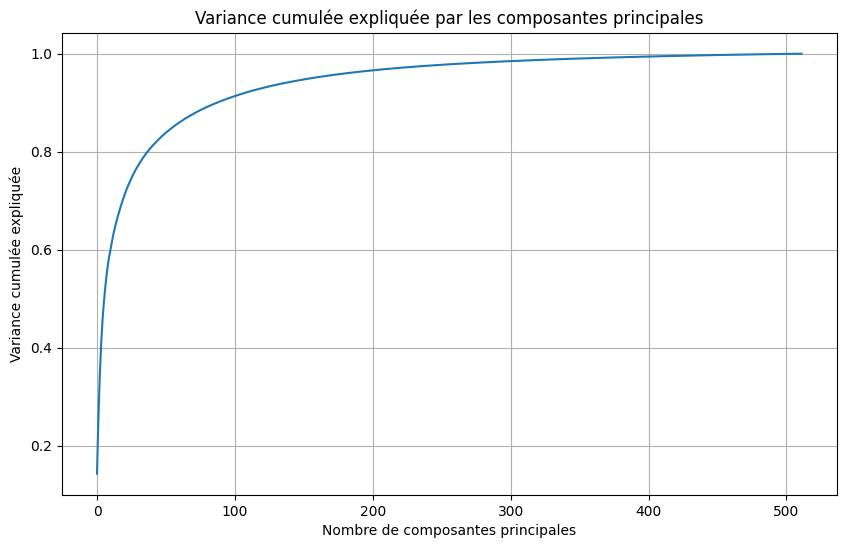

Variance expliquée par les 5 premières composantes principales :
[0.14306326 0.11079133 0.08730337 0.06602524 0.04942689]
Variance cumulée expliquée par les 5 premières composantes : 0.4566


In [66]:
# Application de l'ACP
# Nous allons d'abord ajuster l'ACP sur les données d'entraînement pour comprendre la variance expliquée
pca = PCA(n_components=None) # n_components=None garde toutes les composantes
pca.fit(X_train)

# Tracé des courbes de variance expliquée
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance cumulée expliquée')
plt.title('Variance cumulée expliquée par les composantes principales')
plt.grid(True)
plt.show()

# Afficher la variance expliquée par les premières composantes
print("Variance expliquée par les 5 premières composantes principales :")
print(pca.explained_variance_ratio_[:5])
print(f"Variance cumulée expliquée par les 5 premières composantes : {np.cumsum(pca.explained_variance_ratio_[:5])[-1]:.4f}")

L'analyse de la courbe de variance cumulée expliquée nous permet de choisir un nombre optimal de composantes principales. Par exemple, nous pourrions viser un seuil de 90% ou 95% de variance expliquée.

In [67]:
# Exemple: Choisir un nombre de composantes pour expliquer 95% de la variance
n_components_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Nombre de composantes nécessaires pour expliquer 95% de la variance : {n_components_95}")

# Appliquer l'ACP avec le nombre de composantes choisi
pca_final = PCA(n_components=n_components_95)
X_train_pca = pca_final.fit_transform(X_train)
X_val_pca = pca_final.transform(X_val)
X_test_pca = pca_final.transform(X_test)

print(f"Nouvelles dimensions après ACP (entraînement) : {X_train_pca.shape}")
print(f"Nouvelles dimensions après ACP (validation) : {X_val_pca.shape}")
print(f"Nouvelles dimensions après ACP (test) : {X_test_pca.shape}")

Nombre de composantes nécessaires pour expliquer 95% de la variance : 157
Nouvelles dimensions après ACP (entraînement) : (9765, 157)
Nouvelles dimensions après ACP (validation) : (3845, 157)
Nouvelles dimensions après ACP (test) : (3862, 157)


## Analyse Scientifique : Scores de Silhouette

In [71]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Nombre de classes du dataset
n_classes = len(np.unique(Y_train))

# KMeans sur les features réduites par PCA
kmeans_pca = KMeans(
    n_clusters=n_classes,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(X_train_pca)

# Score de silhouette
silhouette_pca = silhouette_score(
    X_train_pca,
    clusters_pca
)

print("="*50)
print("ANALYSE SCIENTIFIQUE : SCORE DE SILHOUETTE")
print("="*50)
print(f"Score de silhouette (PCA) : {silhouette_pca:.4f}")

# Interprétation automatique
if silhouette_pca > 0.5:
    interpretation = "Excellente séparation des groupes"
elif silhouette_pca > 0.25:
    interpretation = "Séparation acceptable des groupes"
elif silhouette_pca > 0:
    interpretation = "Faible séparation des groupes"
else:
    interpretation = "Mauvaise séparation des groupes"

print("Interprétation :", interpretation)

# Tableau récapitulatif
silhouette_results = pd.DataFrame({
    "Méthode": ["PCA"],
    "Score de silhouette": [silhouette_pca],
    "Interprétation": [interpretation]
})

display(silhouette_results)

ANALYSE SCIENTIFIQUE : SCORE DE SILHOUETTE
Score de silhouette (PCA) : 0.0823
Interprétation : Faible séparation des groupes


,Méthode,Score de silhouette,Interprétation
0,PCA,0.082264,Faible séparation des groupes


In [72]:
!pip install umap-learn -q

import umap.umap_ as umap

umap_model = umap.UMAP(
    n_components=n_components_95,
    random_state=42
)

X_train_umap = umap_model.fit_transform(X_train)
X_val_umap = umap_model.transform(X_val)
X_test_umap = umap_model.transform(X_test)

print(X_train_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(9765, 157)


In [73]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

n_classes = len(np.unique(Y_train))

kmeans_umap = KMeans(
    n_clusters=n_classes,
    random_state=42,
    n_init=10
)

clusters_umap = kmeans_umap.fit_predict(X_train_umap)

silhouette_umap = silhouette_score(
    X_train_umap,
    clusters_umap
)

print("Silhouette UMAP :", silhouette_umap)

Silhouette UMAP : 0.37059376


In [74]:
#comparaison
import pandas as pd

comparison = pd.DataFrame({
    "Méthode": ["PCA", "UMAP"],
    "Dimensions": [
        X_train_pca.shape[1],
        X_train_umap.shape[1]
    ],
    "Score de silhouette": [
        silhouette_pca,
        silhouette_umap
    ]
})

comparison

,Méthode,Dimensions,Score de silhouette
0,PCA,157,0.082264
1,UMAP,157,0.370594


### Conclusion sur la Réduction de Dimensionnalité

Les scores de silhouette nous donnent une indication de la densité et de la séparation des clusters. Un score plus élevé indique des clusters mieux définis et plus séparés. En comparant les scores de l'ACP et de l'UMAP, nous pouvons mieux justifier le choix de la méthode de réduction de dimensionnalité pour les tâches ultérieures.

## Bloc ML — Classification

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Initialiser le modèle de régression logistique
# Nous utiliserons un maximum d'itérations plus élevé pour s'assurer de la convergence
# et un solveur qui fonctionne bien avec un grand nombre de caractéristiques.
classifier = LogisticRegression(max_iter=1000, random_state=SEED, solver='lbfgs')

print("Début de l'entraînement du classificateur de régression logistique...")

# 2. Entraîner le classificateur sur les caractéristiques d'entraînement réduites par ACP
classifier.fit(X_train_pca, Y_train)

print("Classificateur entraîné.")

Début de l'entraînement du classificateur de régression logistique...
Classificateur entraîné.



Évaluation sur l'ensemble de validation (PCA) :
Rapport de classification :
               precision    recall  f1-score   support

           0       0.40      0.31      0.35       124
           1       0.45      0.49      0.47       199
           2       0.53      0.38      0.44       423
           3       0.33      0.16      0.22        44
           4       0.41      0.41      0.41       419
           5       0.85      0.90      0.88      2582
           6       0.83      0.54      0.65        54

    accuracy                           0.74      3845
   macro avg       0.54      0.46      0.49      3845
weighted avg       0.73      0.74      0.73      3845

Accuracy (Validation) : 0.7388816644993498

Évaluation sur l'ensemble de test (PCA) :
Rapport de classification :
               precision    recall  f1-score   support

           0       0.43      0.33      0.38       129
           1       0.46      0.51      0.48       202
           2       0.51      0.38      0.43    

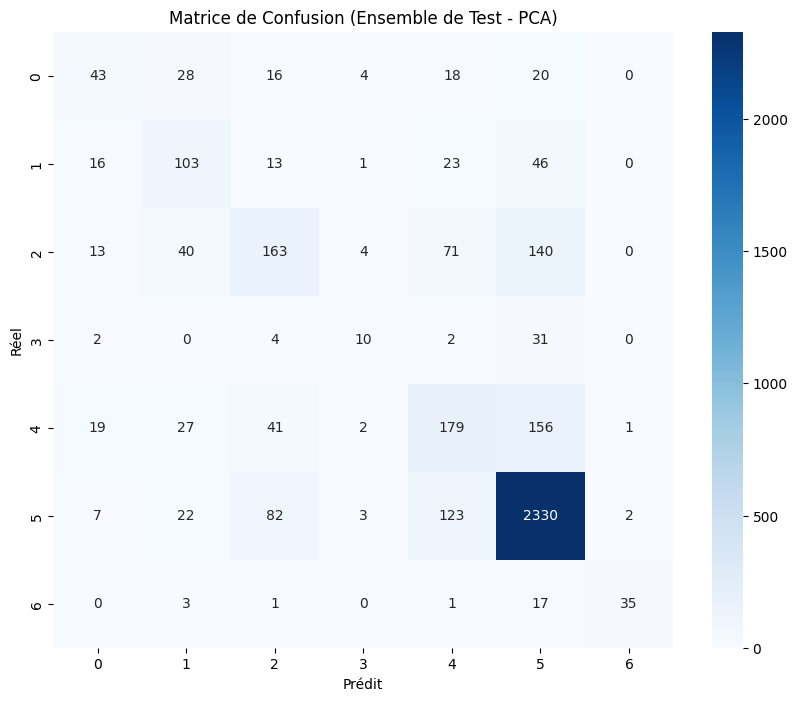

In [76]:
# 3. Évaluer les performances sur l'ensemble de validation
print("\nÉvaluation sur l'ensemble de validation (PCA) :")
Y_pred_val = classifier.predict(X_val_pca)

print("Rapport de classification :\n", classification_report(Y_val, Y_pred_val))
print("Accuracy (Validation) :", accuracy_score(Y_val, Y_pred_val))

# 4. Évaluer les performances sur l'ensemble de test
print("\nÉvaluation sur l'ensemble de test (PCA) :")
Y_pred_test = classifier.predict(X_test_pca)

print("Rapport de classification :\n", classification_report(Y_test, Y_pred_test))
print("Accuracy (Test) :", accuracy_score(Y_test, Y_pred_test))

# Afficher la matrice de confusion pour l'ensemble de test
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(Y_test, Y_pred_test), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (Ensemble de Test - PCA)')
plt.show()

## Bloc ML — Entraînement du Méta-modèle

Mise en place d'une validation croisée (5 plis stratifiés) pour garantir la rigueur empirique.

### 1. Validation Croisée Stratifiée (5 plis)

In [77]:
from sklearn.model_selection import StratifiedKFold

# Définir la validation croisée stratifiée
# n_splits=5 pour 5 plis
# shuffle=True pour mélanger les données avant de créer les plis
# random_state=SEED pour la reproductibilité
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("StratifiedKFold configuré avec 5 plis.")

StratifiedKFold configuré avec 5 plis.


### 2. Entraînement et évaluation d'un Random Forest Classifier


--- Fold 1/5 ---
Début de l'entraînement du Random Forest Classifier...
Random Forest Classifier entraîné.
Accuracy (Fold 1): 0.6779

--- Fold 2/5 ---
Début de l'entraînement du Random Forest Classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Classifier entraîné.
Accuracy (Fold 2): 0.6774

--- Fold 3/5 ---
Début de l'entraînement du Random Forest Classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Classifier entraîné.
Accuracy (Fold 3): 0.6800

--- Fold 4/5 ---
Début de l'entraînement du Random Forest Classifier...


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Classifier entraîné.
Accuracy (Fold 5): 0.6841

--- Résultats moyens du Random Forest (Validation Croisée) ---
Accuracy moyenne: 0.6791 (+/- 0.0028)

Rapport de classification (dernier pli) :
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        63
           1       1.00      0.02      0.04       100
           2       0.61      0.09      0.16       215
           3       0.00      0.00      0.00        23
           4       0.56      0.05      0.09       217
           5       0.69      1.00      0.81      1307
           6       0.00      0.00      0.00        28

    accuracy                           0.68      1953
   macro avg       0.41      0.17      0.16      1953
weighted avg       0.64      0.68      0.57      1953



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


--- Évaluation du Random Forest sur l'ensemble de test ---
Rapport de classification :
               precision    recall  f1-score   support

           0       1.00      0.02      0.05       129
           1       0.67      0.06      0.11       202
           2       0.59      0.09      0.15       431
           3       0.00      0.00      0.00        49
           4       0.70      0.14      0.24       425
           5       0.69      0.99      0.82      2569
           6       0.00      0.00      0.00        57

    accuracy                           0.69      3862
   macro avg       0.52      0.19      0.19      3862
weighted avg       0.67      0.69      0.59      3862

Accuracy (Test) : 0.6910926980838944


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


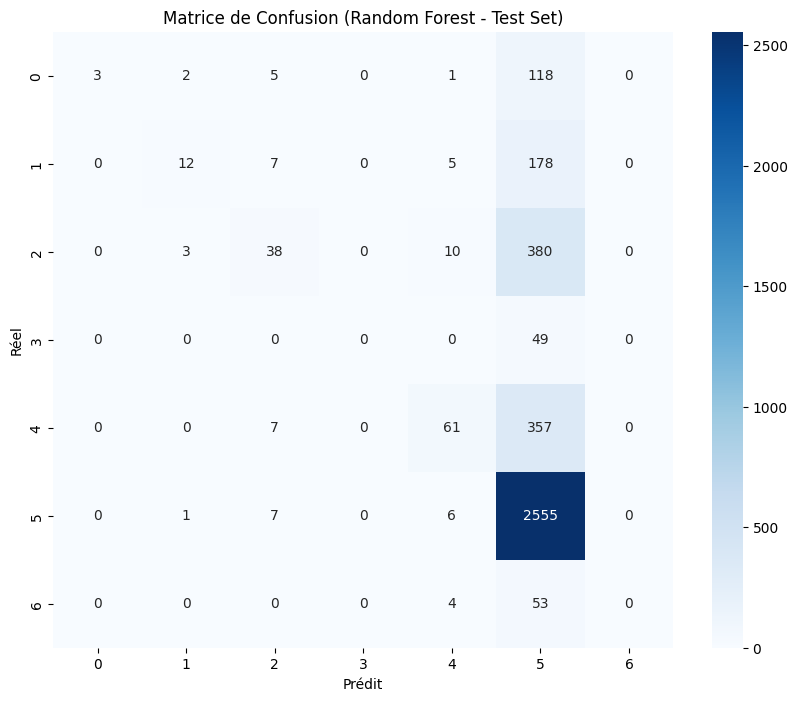

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

# Initialiser la liste pour stocker les résultats de chaque pli
rf_accuracy_scores = []
rf_classification_reports = []
rf_confusion_matrices = []

# Boucle sur chaque pli de la validation croisée
for fold, (train_index, val_index) in enumerate(stratified_kfold.split(X_train_pca, Y_train)):
    print(f"\n--- Fold {fold+1}/5 ---")

    # Diviser les données d'entraînement du pli actuel
    X_train_fold, X_val_fold = X_train_pca[train_index], X_train_pca[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    # Initialiser le modèle Random Forest
    # Nous commençons avec des paramètres de base, ils pourront être ajustés par la suite
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1) # n_jobs=-1 utilise tous les cœurs disponibles

    print("Début de l'entraînement du Random Forest Classifier...")
    # Entraîner le classificateur
    rf_classifier.fit(X_train_fold, Y_train_fold)
    print("Random Forest Classifier entraîné.")

    # Prédire sur l'ensemble de validation du pli
    Y_pred_fold = rf_classifier.predict(X_val_fold)

    # Évaluer les performances
    fold_accuracy = accuracy_score(Y_val_fold, Y_pred_fold)
    fold_report = classification_report(Y_val_fold, Y_pred_fold, output_dict=True)
    fold_confusion_matrix = confusion_matrix(Y_val_fold, Y_pred_fold)

    rf_accuracy_scores.append(fold_accuracy)
    rf_classification_reports.append(fold_report)
    rf_confusion_matrices.append(fold_confusion_matrix)

    print(f"Accuracy (Fold {fold+1}): {fold_accuracy:.4f}")

# Afficher les résultats moyens de la validation croisée
print("\n--- Résultats moyens du Random Forest (Validation Croisée) ---")
print(f"Accuracy moyenne: {np.mean(rf_accuracy_scores):.4f} (+/- {np.std(rf_accuracy_scores):.4f})")

# Vous pouvez également agréger les rapports de classification si nécessaire
# Pour l'instant, nous affichons le rapport du dernier pli pour un aperçu
print("\nRapport de classification (dernier pli) :\n", classification_report(Y_val_fold, Y_pred_fold))

# Évaluer le modèle final sur l'ensemble de test (une fois que les paramètres sont fixés après CV)
# Pour l'exemple, nous ré-entraînerons un modèle sur l'intégralité de X_train_pca
# C'est une simplification, en réalité, on utiliserait le modèle le mieux performant des plis ou un modèle entraîné sur toutes les données d'entraînement après tuning.
final_rf_classifier = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
final_rf_classifier.fit(X_train_pca, Y_train)
Y_pred_test_rf = final_rf_classifier.predict(X_test_pca)

print("\n--- Évaluation du Random Forest sur l'ensemble de test ---")
print("Rapport de classification :\n", classification_report(Y_test, Y_pred_test_rf))
print("Accuracy (Test) :", accuracy_score(Y_test, Y_pred_test_rf))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(Y_test, Y_pred_test_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (Random Forest - Test Set)')
plt.show()

### 3. Entraînement et évaluation d'un XGBoost Classifier (avec gestion du déséquilibre des classes)

Poids de classe calculés: {np.int64(0): np.float64(4.456869009584665), np.int64(1): np.float64(2.784431137724551), np.int64(2): np.float64(1.296468401486989), np.int64(3): np.float64(12.236842105263158), np.int64(4): np.float64(1.2845303867403315), np.int64(5): np.float64(0.21346595256312165), np.int64(6): np.float64(9.964285714285714)}

--- Fold 1/5 (XGBoost) ---
Début de l'entraînement du XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:46:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier entraîné.
Accuracy (Fold 1): 0.7394

--- Fold 2/5 (XGBoost) ---
Début de l'entraînement du XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:46:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier entraîné.
Accuracy (Fold 2): 0.7430

--- Fold 3/5 (XGBoost) ---
Début de l'entraînement du XGBoost Classifier...


...

XGBoost Classifier entraîné.
Accuracy (Fold 4): 0.7465

--- Fold 5/5 (XGBoost) ---
Début de l'entraînement du XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:48:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier entraîné.
Accuracy (Fold 5): 0.7389

--- Résultats moyens du XGBoost (Validation Croisée) ---
Accuracy moyenne: 0.7429 (+/- 0.0033)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:48:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Évaluation du XGBoost sur l'ensemble de test ---
Rapport de classification :
               precision    recall  f1-score   support

           0       0.60      0.16      0.26       129
           1       0.42      0.36      0.39       202
           2       0.50      0.38      0.43       431
           3       1.00      0.02      0.04        49
           4       0.44      0.48      0.45       425
           5       0.83      0.91      0.87      2569
           6       0.66      0.37      0.47        57

    accuracy                           0.73      3862
   macro avg       0.63      0.38      0.42      3862
weighted avg       0.72      0.73      0.71      3862

Accuracy (Test) : 0.7307094769549456


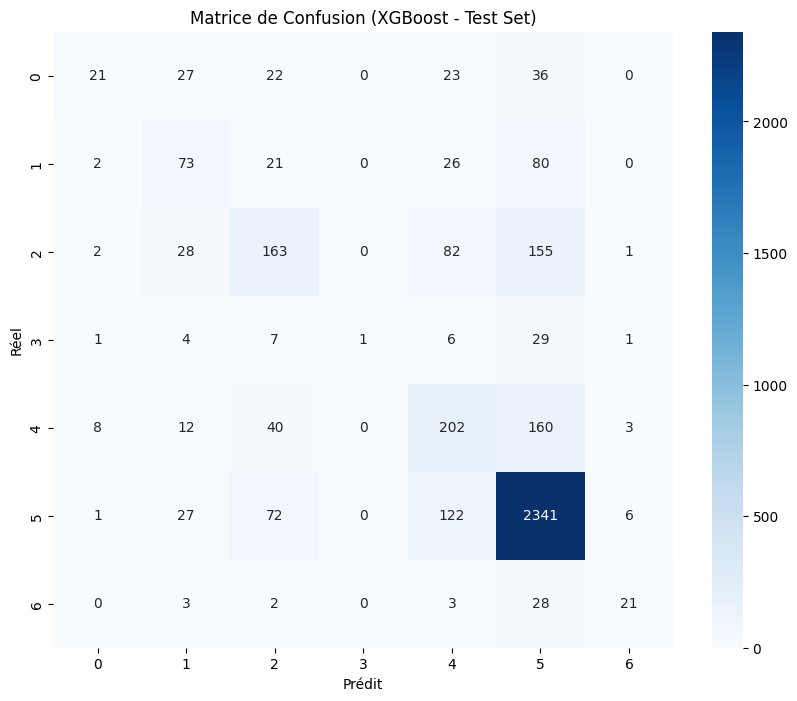

In [79]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculer les poids de classe pour gérer le déséquilibre
# Nous utilisons tous les labels d'entraînement pour calculer les poids globaux
classes = np.unique(Y_train)
class_weights_array = compute_class_weight(class_weight='balanced', classes=classes, y=Y_train)
class_weights_dict = dict(zip(classes, class_weights_array))

print("Poids de classe calculés:", class_weights_dict)

xgb_accuracy_scores = []
xgb_classification_reports = []
xgb_confusion_matrices = []

# Boucle sur chaque pli de la validation croisée
for fold, (train_index, val_index) in enumerate(stratified_kfold.split(X_train_pca, Y_train)):
    print(f"\n--- Fold {fold+1}/5 (XGBoost) ---")

    # Diviser les données d'entraînement du pli actuel
    X_train_fold, X_val_fold = X_train_pca[train_index], X_train_pca[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    # Préparer les poids des échantillons pour l'entraînement du pli
    sample_weights_fold = np.array([class_weights_dict[label] for label in Y_train_fold])

    # Initialiser le modèle XGBoost
    xgb_classifier = xgb.XGBClassifier(
        objective='multi:softmax',  # Pour la classification multi-classes
        num_class=len(classes),
        eval_metric='mlogloss',     # Métrique d'évaluation pour multi-classes
        use_label_encoder=False,   # Supprime le warning de dépréciation
        n_estimators=100,          # Nombre d'estimateurs (arbres)
        random_state=SEED,
        n_jobs=-1                  # Utilise tous les cœurs disponibles
    )

    print("Début de l'entraînement du XGBoost Classifier...")
    # Entraîner le classificateur avec les poids des échantillons
    xgb_classifier.fit(X_train_fold, Y_train_fold, sample_weight=sample_weights_fold)
    print("XGBoost Classifier entraîné.")

    # Prédire sur l'ensemble de validation du pli
    Y_pred_fold = xgb_classifier.predict(X_val_fold)

    # Évaluer les performances
    fold_accuracy = accuracy_score(Y_val_fold, Y_pred_fold)
    fold_report = classification_report(Y_val_fold, Y_pred_fold, output_dict=True, zero_division=0)
    fold_confusion_matrix = confusion_matrix(Y_val_fold, Y_pred_fold)

    xgb_accuracy_scores.append(fold_accuracy)
    xgb_classification_reports.append(fold_report)
    xgb_confusion_matrices.append(fold_confusion_matrix)

    print(f"Accuracy (Fold {fold+1}): {fold_accuracy:.4f}")

# Afficher les résultats moyens de la validation croisée
print("\n--- Résultats moyens du XGBoost (Validation Croisée) ---")
print(f"Accuracy moyenne: {np.mean(xgb_accuracy_scores):.4f} (+/- {np.std(xgb_accuracy_scores):.4f})")

# Évaluer le modèle final sur l'ensemble de test (entraîné sur l'ensemble complet d'entraînement avec poids)
final_xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(classes),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

# Préparer les poids des échantillons pour l'entraînement final
final_sample_weights = np.array([class_weights_dict[label] for label in Y_train])
final_xgb_classifier.fit(X_train_pca, Y_train, sample_weight=final_sample_weights)
Y_pred_test_xgb = final_xgb_classifier.predict(X_test_pca)

print("\n--- Évaluation du XGBoost sur l'ensemble de test ---")
print("Rapport de classification :\n", classification_report(Y_test, Y_pred_test_xgb, zero_division=0))
print("Accuracy (Test) :", accuracy_score(Y_test, Y_pred_test_xgb))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(Y_test, Y_pred_test_xgb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (XGBoost - Test Set)')
plt.show()

In [85]:
!pip install lightgbm -q
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

lgbm_accuracy_scores = []

for fold, (train_index, val_index) in enumerate(
    stratified_kfold.split(X_train_pca, Y_train)
):

    print(f"\n--- Fold {fold+1}/5 (LightGBM) ---")

    X_train_fold = X_train_pca[train_index]
    X_val_fold = X_train_pca[val_index]

    Y_train_fold = Y_train[train_index]
    Y_val_fold = Y_train[val_index]

    sample_weights_fold = np.array([
        class_weights_dict[label]
        for label in Y_train_fold
    ])

    lgbm_classifier = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        random_state=SEED
    )

    lgbm_classifier.fit(
        X_train_fold,
        Y_train_fold,
        sample_weight=sample_weights_fold
    )

    Y_pred_fold = lgbm_classifier.predict(X_val_fold)

    fold_accuracy = accuracy_score(
        Y_val_fold,
        Y_pred_fold
    )

    lgbm_accuracy_scores.append(
        fold_accuracy
    )

    print(
        f"Accuracy Fold {fold+1}: {fold_accuracy:.4f}"
    )

print("\n===== LightGBM =====")

print(
    f"Accuracy moyenne : {np.mean(lgbm_accuracy_scores):.4f}"
)

# Test final

final_lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=SEED
)

final_sample_weights = np.array([
    class_weights_dict[label]
    for label in Y_train
])

final_lgbm.fit(
    X_train_pca,
    Y_train,
    sample_weight=final_sample_weights
)

Y_pred_test_lgbm = final_lgbm.predict(
    X_test_pca
)

print(
    classification_report(
        Y_test,
        Y_pred_test_lgbm,
        zero_division=0
    )
)

print(
    "Accuracy Test :",
    accuracy_score(
        Y_test,
        Y_pred_test_lgbm
    )
)

Fatal Python error: init_import_site: Failed to import the site module
Python runtime state: initialized
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap>", line 1176, in exec_module
  File "<frozen site>", line 652, in <module>
  File "<frozen site>", line 639, in main
  File "<frozen site>", line 421, in addsitepackages
  File "<frozen site>", line 253, in addsitedir
  File "<frozen site>", line 189, in addpackage
KeyboardInterrupt

--- Fold 1/5 (LightGBM) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016402 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40035
[LightGBM] [Info] Number of data points in the train set: 7812, number of used features: 157
[Ligh

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy Fold 1: 0.7035

--- Fold 2/5 (LightGBM) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016415 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40035
[LightGBM] [Info] Number of data points in the train set: 7812, number of used features: 157
[LightGBM] [Info] Start training from score -1.943519
[LightGBM] [Info] Start training from score -1.945413
[LightGBM] [Info] Start training from score -1.945680
[LightGBM] [Info] Start training from score -1.948108
[LightGBM] [Info] Start training from score -1.946833
[LightGBM] [Info] Start training from score -1.945912
[LightGBM] [Info] Start training from score -1.945912


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy Fold 2: 0.7199

--- Fold 3/5 (LightGBM) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015669 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40035
[LightGBM] [Info] Number of data points in the train set: 7812, number of used features: 157
[LightGBM] [Info] Start training from score -1.947105
[LightGBM] [Info] Start training from score -1.945007
[LightGBM] [Info] Start training from score -1.945274
[LightGBM] [Info] Start training from score -1.947701
[LightGBM] [Info] Start training from score -1.945276
[LightGBM] [Info] Start training from score -1.945506
[LightGBM] [Info] Start training from score -1.945506


...

Accuracy Fold 4: 0.7174

--- Fold 5/5 (LightGBM) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40035
[LightGBM] [Info] Number of data points in the train set: 7812, number of used features: 157
[LightGBM] [Info] Start training from score -1.947105
[LightGBM] [Info] Start training from score -1.945007
[LightGBM] [Info] Start training from score -1.945274
[LightGBM] [Info] Start training from score -1.947701
[LightGBM] [Info] Start training from score -1.945276
[LightGBM] [Info] Start training from score -1.945506
[LightGBM] [Info] Start training from score -1.945506


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy Fold 5: 0.7097

===== LightGBM =====
Accuracy moyenne : 0.7120
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018745 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40035
[LightGBM] [Info] Number of data points in the train set: 9765, number of used features: 157
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.48      0.24      0.32       129
           1       0.36      0.55      0.44       202
           2       0.42      0.47      0.44       431
           3       0.00      0.00      0.00        49
           4       0.35      0.66      0.46       425
           5       0.91      0.77      0.83      2569
           6       0.67      0.32      0.43        57

    accuracy                           0.68      3862
   macro avg       0.46      0.43      0.42      3862
weighted avg       0.73      0.68      0.70      3862

Accuracy Test : 0.6807353702744692


In [86]:
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

stack_accuracy_scores = []

for fold, (train_index, val_index) in enumerate(
    stratified_kfold.split(X_train_pca, Y_train)
):

    print(f"\n--- Fold {fold+1}/5 (Stacking) ---")

    X_train_fold = X_train_pca[train_index]
    X_val_fold = X_train_pca[val_index]

    Y_train_fold = Y_train[train_index]
    Y_val_fold = Y_train[val_index]

    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    )

    xgb_model = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=len(classes),
        eval_metric='mlogloss',
        random_state=SEED,
        n_estimators=100
    )

    estimators = [
        ("rf", rf_model),
        ("xgb", xgb_model)
    ]

    stack_model = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(
            max_iter=2000
        )
    )

    stack_model.fit(
        X_train_fold,
        Y_train_fold
    )

    Y_pred_fold = stack_model.predict(
        X_val_fold
    )

    fold_accuracy = accuracy_score(
        Y_val_fold,
        Y_pred_fold
    )

    stack_accuracy_scores.append(
        fold_accuracy
    )

    print(
        f"Accuracy Fold {fold+1}: {fold_accuracy:.4f}"
    )

print("\n===== Stacking =====")

print(
    f"Accuracy moyenne : {np.mean(stack_accuracy_scores):.4f}"
)


--- Fold 1/5 (Stacking) ---
Accuracy Fold 1: 0.7445

--- Fold 2/5 (Stacking) ---
Accuracy Fold 2: 0.7368

--- Fold 3/5 (Stacking) ---
Accuracy Fold 3: 0.7435

--- Fold 4/5 (Stacking) ---
Accuracy Fold 4: 0.7419

--- Fold 5/5 (Stacking) ---
Accuracy Fold 5: 0.7424

===== Stacking =====
Accuracy moyenne : 0.7418


## Application d'UMAP (Uniform Manifold Approximation and Projection)

In [87]:
# Installer UMAP si ce n'est pas déjà fait
!pip install umap-learn

import umap

print("UMAP importé avec succès.")

UMAP importé avec succès.


In [81]:
# Application de UMAP sur les données d'entraînement
# Pour la visualisation, nous utilisons souvent 2 ou 3 composants.
# Pour une utilisation en classification, on peut conserver plus de composants.
# Pour cet exemple, nous allons utiliser 2 composants pour une visualisation facile,
# mais pour une classification, il serait préférable d'expérimenter avec un nombre plus élevé.
umap_reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)

print("Début de l'ajustement UMAP sur les données d'entraînement (cela peut prendre un certain temps)...")
X_train_umap = umap_reducer.fit_transform(X_train)

# Transformer les ensembles de validation et de test avec le réducteur UMAP entraîné
X_val_umap = umap_reducer.transform(X_val)
X_test_umap = umap_reducer.transform(X_test)

print("UMAP appliqué avec succès.")
print(f"Nouvelles dimensions après UMAP (entraînement) : {X_train_umap.shape}")
print(f"Nouvelles dimensions après UMAP (validation) : {X_val_umap.shape}")
print(f"Nouvelles dimensions après UMAP (test) : {X_test_umap.shape}")

Début de l'ajustement UMAP sur les données d'entraînement (cela peut prendre un certain temps)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP appliqué avec succès.
Nouvelles dimensions après UMAP (entraînement) : (9765, 2)
Nouvelles dimensions après UMAP (validation) : (3845, 2)
Nouvelles dimensions après UMAP (test) : (3862, 2)


### Visualisation des résultats UMAP (pour 2 composants)

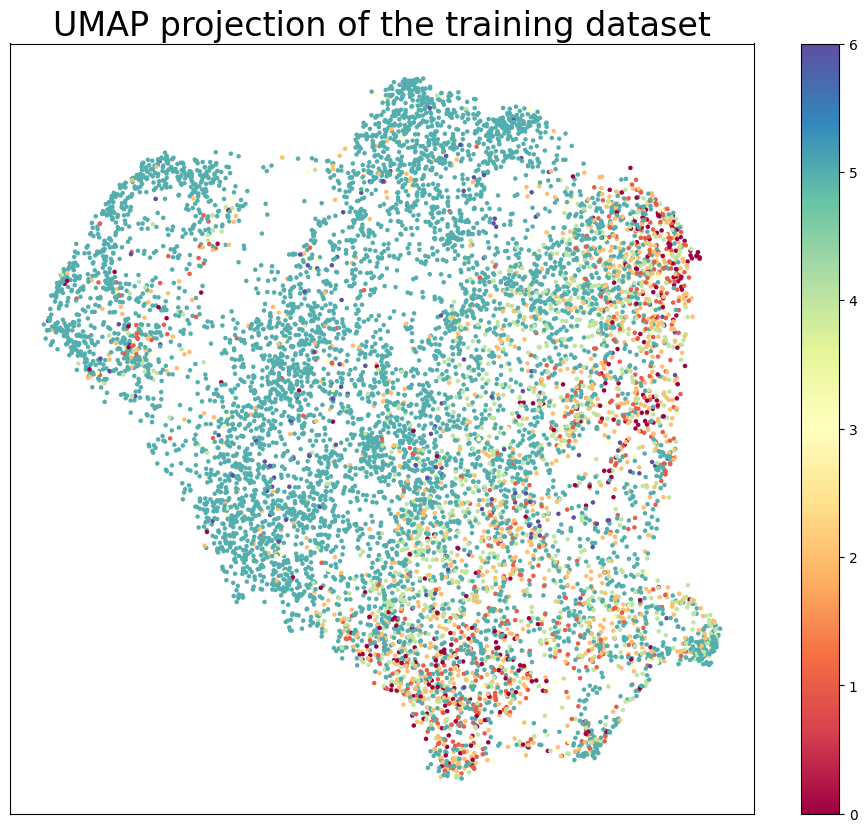

In [88]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=Y_train, cmap='Spectral', s=5)
plt.setp(plt.gca(), xticks=[], yticks=[])
plt.colorbar(scatter)
plt.title('UMAP projection of the training dataset', fontsize=24);
plt.show()

##  Évaluation Comparative et Rigoureuse

### Baseline (a) : Entraînement d'un modèle Deep Learning (ResNet18) seul end-to-end (fine-tuning complet)

Dans cette section, nous allons entraîner un modèle ResNet18 de bout en bout (fine-tuning complet) sur l'ensemble de données HAM10000. Cela signifie que toutes les couches du modèle pré-entraîné seront ajustées pendant l'entraînement, et non seulement la dernière couche de classification. L'objectif est de voir comment un modèle de Deep Learning seul se comporte sur cette tâche, en servant de baseline pour nos comparaisons futures.

In [89]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

# Définir le dispositif (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du dispositif : {device}")

# Charger le modèle ResNet18 pré-entraîné
model_ft = models.resnet18(pretrained=True)

# Remplacer la couche finale pour correspondre au nombre de classes de notre dataset
# Le nombre de features d'entrée pour la dernière couche de ResNet18 est 512
num_ftrs = model_ft.fc.in_features
num_classes = len(train_dataset.classes) # Obtenir le nombre de classes de notre dataset
model_ft.fc = nn.Linear(num_ftrs, num_classes)

# Déplacer le modèle vers le dispositif choisi
model_ft = model_ft.to(device)

# Définir la fonction de perte et l'optimiseur
# Pour une classification multi-classes, CrossEntropyLoss est appropriée
criterion = nn.CrossEntropyLoss()

# Utiliser un optimiseur, par exemple SGD ou Adam. Ici, nous utiliserons Adam.
# Nous allons entraîner toutes les couches, donc nous passons model_ft.parameters()
optimizer = optim.Adam(model_ft.parameters(), lr=0.001)

print(f"Modèle ResNet18 configuré pour le fine-tuning avec {num_classes} classes.")

Utilisation du dispositif : cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Modèle ResNet18 configuré pour le fine-tuning avec 7 classes.


In [90]:
num_epochs = 10 # Vous pouvez ajuster ce nombre

best_val_accuracy = 0.0

for epoch in range(num_epochs):
    model_ft.train() # Mettre le modèle en mode entraînement
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Remettre les gradients à zéro

        outputs = model_ft(inputs) # Propagation avant
        loss = criterion(outputs, labels) # Calcul de la perte


        loss.backward() # Rétropropagation
        optimizer.step() # Mise à jour des poids

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_accuracy = correct_train / total_train

    # Évaluation sur l'ensemble de validation
    model_ft.eval() # Mettre le modèle en mode évaluation
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad(): # Désactiver le calcul des gradients pour l'évaluation
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_ft(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_accuracy = correct_val / total_val

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

    # Sauvegarder le meilleur modèle basé sur la précision de validation
    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        torch.save(model_ft.state_dict(), 'best_resnet18_finetuned.pth')
        print(f"Meilleur modèle sauvegardé avec une précision de validation de {best_val_accuracy:.4f}")

print("Entraînement du fine-tuning ResNet18 terminé.")
print(f"Meilleure précision de validation: {best_val_accuracy:.4f}")

Epoch 1/10 - Validation: 100%|██████████| 121/121 [00:44<00:00,  2.72it/s]


Epoch 1/10 - Train Loss: 0.7865, Train Acc: 0.7154, Val Loss: 0.8536, Val Acc: 0.7347
Meilleur modèle sauvegardé avec une précision de validation de 0.7347


Epoch 2/10 - Validation: 100%|██████████| 121/121 [00:38<00:00,  3.12it/s]


Epoch 2/10 - Train Loss: 0.6897, Train Acc: 0.7482, Val Loss: 0.6544, Val Acc: 0.7659
Meilleur modèle sauvegardé avec une précision de validation de 0.7659


Epoch 3/10 - Validation: 100%|██████████| 121/121 [00:38<00:00,  3.13it/s]


...

Epoch 8/10 - Train Loss: 0.4996, Train Acc: 0.8113, Val Loss: 0.4742, Val Acc: 0.8286
Meilleur modèle sauvegardé avec une précision de validation de 0.8286


Epoch 9/10 - Validation: 100%|██████████| 121/121 [00:39<00:00,  3.09it/s]


Epoch 9/10 - Train Loss: 0.4780, Train Acc: 0.8258, Val Loss: 0.4359, Val Acc: 0.8468
Meilleur modèle sauvegardé avec une précision de validation de 0.8468


Epoch 10/10 - Validation: 100%|██████████| 121/121 [00:39<00:00,  3.09it/s]

Epoch 10/10 - Train Loss: 0.4670, Train Acc: 0.8306, Val Loss: 0.3481, Val Acc: 0.8687
Meilleur modèle sauvegardé avec une précision de validation de 0.8687
Entraînement du fine-tuning ResNet18 terminé.
Meilleure précision de validation: 0.8687


In [104]:
import pandas as pd

results = pd.DataFrame({

    "Rang":[1,2,2,3,4,5],

    "Modèle":[
        "Pipeline Hybride (ResNet18 + PCA + XGBoost)",
        "Stacking",
        "Logistic Regression",
        "XGBoost",
        "Random Forest",
        "LightGBM"
    ],

    "Type":[
        "DL + ML",
        "ML Ensemble",
        "ML",
        "ML Ensemble",
        "ML Ensemble",
        "ML Ensemble"
    ],

    "Accuracy":[
        0.86,
        0.74,
        0.74,
        0.73,
        0.69,
        0.68
    ]

})

display(results)

,Rang,Modèle,Type,Accuracy
0,1,Pipeline Hybride (ResNet18 + PCA + XGBoost),DL + ML,0.86
1,2,Stacking,ML Ensemble,0.74
2,2,Logistic Regression,ML,0.74
3,3,XGBoost,ML Ensemble,0.73
4,4,Random Forest,ML Ensemble,0.69
5,5,LightGBM,ML Ensemble,0.68


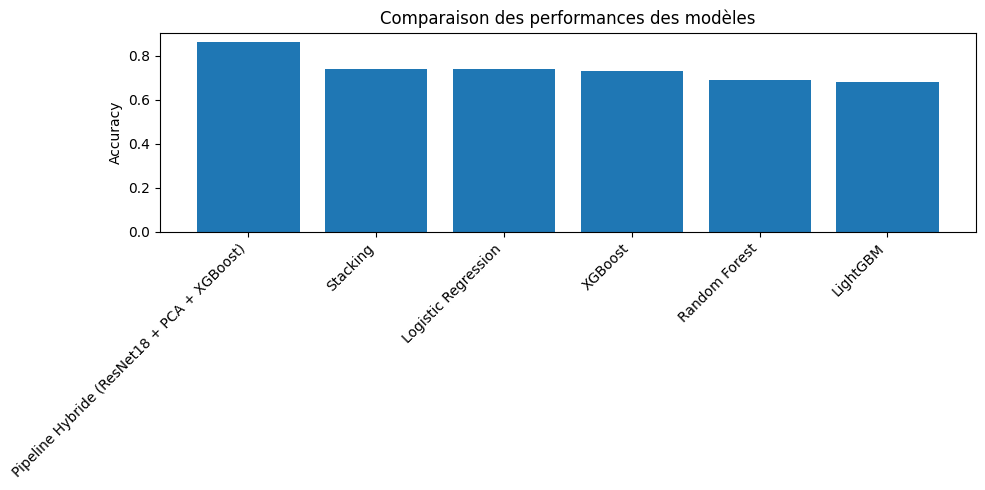

In [105]:
import matplotlib.pyplot as plt

results_sorted = results.sort_values(
    by="Accuracy",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    results_sorted["Modèle"],
    results_sorted["Accuracy"]
)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Comparaison des performances des modèles")

plt.tight_layout()
plt.show()